## Basic Rotterdam-Antwerp trip  
This notebook shows the simple route without locks. There are two routes: Nieuwe Maas and Oude Maas. Some edges had to be removed or forces for these routes. The speed is fixed at 4m/s (which is correct now according to the last cell). 


## TO DO
1. X Clean
2. V Finalise simple route (add reduced depth at chosen setions) 
3. X Test with 2nd vessel
4. Copy simple route and test with Volkerak 
5. Visualise fuel consumption (kg/km and kg/h, first over volkerak then simple route) --> table 
6. Finish analysis Volkerak (extract 2 other cases)
7. Calibrate the other cases (-> create lock objects with the right parametrs) 
8. Find way to run cases in a single code (vessels, routes??, lock) 



## 0. Import libraries

In [1]:
# packages used for creating and geo-locating the graph
import networkx as nx
import shapely

# packages related to the simulation (creating the vessel, running the simulation)
import datetime
import pickle
import simpy
import opentnsim
import opentnsim.fis as fis
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
from opentnsim.graph import mixins as graph_module
from opentnsim.graph.calculations import calculate_length_of_edge

# packages related to the energy module 
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
    add_H2_attributes_to_event_table)

# packages needed for inspecting the output
import pandas as pd
import geopandas as gpd

# packages needed for plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# plot libraries
import folium

import numpy as np

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev47+gbe28de4fe.d20260122


In [2]:
%load_ext autoreload
%autoreload 2

## 0. Load useful methods 

### A) Network functions

In [3]:
# Method to remove edges  
def safe_remove_edge(G, u, v):
    if G.has_edge(u, v):
        G.remove_edge(u, v)
        G.remove_edge(v,u)
        print(f"Removed edge: {u} -> {v} (both directions)")
    else:
        print(f"Edge {u} -> {v} does not exist (already removed).")

In [4]:
# Method to find the closest node
def find_closest_node(G,point):
    distances, idx = nodes_gdf.sindex.nearest(point)
    # return nodes_gdf.iloc[idx[0]].name
    return nodes_gdf.iloc[idx[0]]

### Other methods
Segers also introduces these methods. But I believe those are not needed in the current opentnsim version in combination with the energy module. 

B) Metods to calculate vessel properties <br>
C) Methods to calculate the resistance, power and corresponding emissions <br>
D) Calculate the energy use and emission per time step

### 1. Define object classes

--> moved this to later just before 3. Run simulation 

### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we use the Fairway Information System graph, and make the vessel sail from a container terminal at the Maasvlakte to the Kreekrak locks

#### 2.1 Load FIS graph

In [5]:
# load the processed version from the Fairway Information System graph provided by Rijkswaterstaat
# For FIS version 0.3 
# FG = fis.load_network(version="0.3")

# # Make graph directed 
# FG = FG.to_directed()

with open('FG_correct_distances.pickle', 'rb') as handle:
    FG = pickle.load(handle)

In [6]:
# Printing the data per edge to see what the names are. Check if there is water depth info
for u, v, data in FG.edges(data=True):
    print (u, "->", v)
    print(data)
    break

8861095 -> 8864054
{'GeoType': 'section', 'Name': 'Vaarwegvak van 0 tot 2 - H', 'Length': 2.346, 'GeneralDepth': nan, 'GeneralLength': nan, 'GeneralWidth': nan, 'SeaFairingDepth': nan, 'PushedLength': nan, 'PushedWidth': nan, 'GeneralHeight': nan, 'SeaFairingLength': nan, 'SeaFairingWidth': nan, 'CoupledLength': nan, 'CoupledWidth': nan, 'PushedDepth': nan, 'WidePushedDepth': nan, 'CoupledDepth': nan, 'WidePushedLength': nan, 'WidePushedWidth': nan, 'SeaFairingHeight': nan, 'Id_navigability': nan, 'Classification': nan, 'Code': nan, 'Description': nan, 'length_deg': nan, 'length': 0.0255813258548747, 'Wkt': 'LINESTRING (3.54535894046351 51.727661900382, 3.5602008295784 51.742791566037, 3.56379034355024 51.7453141508194)', 'StartJunctionId': '8861095', 'EndJunctionId': '8864054', 'subgraph': 0, 'length_m': 2345.572872686835, 'geometry': <LINESTRING (3.545 51.728, 3.56 51.743, 3.564 51.745)>}


In [7]:
# FG.nodes[('B4705_B')]['LINESTRING']
FG.nodes[('B4705_B')]

{'n': 'B4705_B',
 'X': 4.485519786010358,
 'Y': 51.90947209143337,
 'geometry': <POINT (4.486 51.909)>,
 'Wkt': 'POINT (4.4855197860103582 51.9094720914333720)'}

In [8]:
# Test to print specific edge data
for u, v, data in FG.edges(data=True):
    if u == 8865973 and v == 8867633:
        print(data)
    else: 
        print("Edge does not exist?")
        break

Edge does not exist?


#### 2.2 Remove edges 
Edges need to be removed to ensure that the vessels sail representative routes.

In [9]:
# Remove Spui (very shallow waterway so most vessels are not able to pass this) 
safe_remove_edge(FG, 'S22992990_A', 'S22992990_B')

# Remove recreational bergediepsluis (not for IWT vessels) 
safe_remove_edge(FG, 'L51819_A', 'L51819_B')

# Remove recreational lock volkerak (not for IWT vessels) 
safe_remove_edge(FG, 'B46500_A', 'B46500_B')

# Remove Rietbaan in nieuwe Maas route (this edge creates a loop)
# TO DO: find out why this removes Noord instead of Rietbaan?? --> difference not so relevant though
safe_remove_edge(FG, '8863048', '8866570') 

Removed edge: S22992990_A -> S22992990_B (both directions)
Removed edge: L51819_A -> L51819_B (both directions)
Removed edge: B46500_A -> B46500_B (both directions)
Removed edge: 8863048 -> 8866570 (both directions)


### 2.2 Create water depth info on edges + visualize on network 
[COPIED FROM SEGERS] 

In this section, we are going to assign a water depth to each individual edge in the graph. At first, the water level (w.r.t. NAP) will be determined for each edge, based on data of waterinfo.nl (RWS). This data is based on a number of measuring points along the Rotterdam-Antwerp corridor.

In [10]:
for u, v in FG.edges():
    # FG.edges[u, v]['Info']['GeneralDepth'] = 4
    FG.edges[u, v]['GeneralDepth'] = 6

#### 2.3 Plan route 

In [11]:
maasvlakte     = shapely.Point(4.056694, 51.947162)
kreekrak       = shapely.Point(4.228202, 51.461103)
meerhout       = shapely.Point(5.096662, 51.098779)
antwerp        = shapely.Point(4.344243, 51.279407)
botlek         = shapely.Point(4.315013, 51.894716)
erasmus_bridge = shapely.Point(4.486020, 51.908346)
krammer        = shapely.Point(4.160114, 51.661751)
hansweert      = shapely.Point(4.010556, 51.455824)

In [12]:
nodes_gdf = gpd.GeoDataFrame(FG.nodes.values(), index=FG.nodes.keys())

In [13]:
# Find closest nodes for the locations
# Start locations
maasvlakte_node  = find_closest_node(FG,maasvlakte)
botlek_node      = find_closest_node(FG,botlek)
# Locks
kreekrak_node    = find_closest_node(FG,kreekrak)
krammer_node     = find_closest_node(FG,krammer)
hansweert_node   = find_closest_node(FG,hansweert)
# End locations
antwerp_node     = find_closest_node(FG,antwerp)
meerhout_node    = find_closest_node(FG,meerhout)
# Nieuwe maas route needs to pass the Erasmus bridge
erasmus_bridge_node      = find_closest_node(FG,erasmus_bridge)

In [14]:
# Use network x to create the different routes
route_OM_RS = nx.shortest_path(FG, botlek_node.name, antwerp_node.name, weight='length_m')

route_NM_RS = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    + nx.shortest_path(FG, erasmus_bridge_node.name, antwerp_node.name, weight='length_m')[1:])

route_OM_ZB = (
    nx.shortest_path(FG, botlek_node.name, hansweert_node.name, weight='length_m')
    + nx.shortest_path(FG, hansweert_node.name, antwerp_node.name, weight='length_m')[1:])

route_NM_ZB = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    +nx.shortest_path(FG, erasmus_bridge_node.name, hansweert_node.name, weight='length_m')[1:]
    + nx.shortest_path(FG, hansweert_node.name, antwerp_node.name, weight='length_m')[1:])


#### Map: route

In [15]:
# Create a map centered between the two points
m = folium.Map(location=[51.83, 4.33], zoom_start = 10, tiles="cartodb positron")

for edge in FG.edges(data = True):
    points_x = list(edge[2]["geometry"].coords.xy[0])
    points_y = list(edge[2]["geometry"].coords.xy[1])
    
    line = []
    for i, _ in enumerate(points_x):
        line.append((points_y[i], points_x[i]))
    
    if edge[0] in route_NM_RS and edge[1] in route_NM_RS:
        folium.PolyLine(line, color = "green", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

    if edge[0] in route_OM_ZB and edge[1] in route_OM_ZB:
        folium.PolyLine(line, color = "yellow", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

    if edge[0] in route_OM_RS and edge[1] in route_OM_RS:
        folium.PolyLine(line, color = "red", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

    if edge[0] in route_NM_ZB and edge[1] in route_NM_ZB:
        folium.PolyLine(line, color = "orange", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)


    # else:
        # folium.PolyLine(line, color = "black", weight = 1, popup = edge[2]["StartJunctionId"]).add_to(m)
        
# Add round marker for Maasvlakte with popup
folium.CircleMarker(
    location=[botlek_node.Y, botlek_node.X],
    radius=8,
    color='green',
    fill=True,
    fill_color='green',
    fill_opacity=0.7,
    popup='Maasvlakte'
).add_to(m)

# Add round marker for Kreekrak with popup
folium.CircleMarker(
    location=[antwerp_node.Y, antwerp_node.X],
    radius=8,
    color='blue',
    fill=True,
    fill_color='blue',
    fill_opacity=0.7,
    popup='Antwerp'
).add_to(m)

# Display the map
m

### 1. Define object classes
This was af the begining of the code first but moved it here. 

In [16]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.core.Movable,                            # Needs to be on top 
        opentnsim.energy.mixins.ConsumesEnergy,
        opentnsim.core.Identifiable,                       # allows to give the object a name and a random ID,
        opentnsim.core.vessel_properties.VesselProperties,
        opentnsim.core.ExtraMetadata,
    ), 
    {}
)

### 3. Run simulation

In [17]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [18]:
# start simpy environment

simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

env.graph = FG

data_vessel_1 = {
    "env": env,
    "name": 'M9 Vessel passing OM+RS',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_installed": 3000.0,      # kW --> test with high number to see if speed is 4 m/s
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    # "P_tot_given": 658,        # 658kW is the constant power when v = 4 m/s
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    # "karpov_correction": False, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_OM_RS[0]]['geometry'],
    "route": route_OM_RS,             # the route to sail
}  # 

data_vessel_2 = {
    "env": env,
    "name": 'M9 Vessel passing NM+RS',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_NM_RS[0]]['geometry'],
    "route": route_NM_RS,             # the route to sail
}  # 

data_vessel_3 = {
    "env": env,
    "name": 'M9 Vessel passing OM+ZB',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_OM_ZB[0]]['geometry'],
    "route": route_OM_ZB,             # the route to sail
}  # 

data_vessel_4 = {
    "env": env,
    "name": 'M9 Vessel passing NM+ZB',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_NM_ZB[0]]['geometry'],
    "route": route_NM_ZB,             # the route to sail
}  # 


# create an instance of the Vessel class using the input dict data_vessel
vessel_1 = Vessel(**data_vessel_1)
vessel_2 = Vessel(**data_vessel_2)
vessel_3 = Vessel(**data_vessel_3)
vessel_4 = Vessel(**data_vessel_4)


# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2))
env.process(mission(env, vessel_3))
env.process(mission(env, vessel_4))


env.run()

### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [19]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'M9 Vessel passing OM+RS' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8861716 to node B17838816_B ...,2024-01-01 00:00:00.000000,0.000000,POINT (4.32003340516321 51.8944476699094)
1,Sailing from node 8861716 to node B17838816_B ...,2024-01-01 00:11:11.550698,2686.202792,POINT (4.331101754547955 51.87131584461907)
2,Sailing from node B17838816_B to node B1783881...,2024-01-01 00:11:11.550698,2686.202792,POINT (4.331101754547955 51.87131584461907)
3,Sailing from node B17838816_B to node B1783881...,2024-01-01 00:11:14.127663,2696.510652,POINT (4.331149675825261 51.871228074742795)
4,Sailing from node B17838816_A to node 8865803 ...,2024-01-01 00:11:14.127663,2696.510652,POINT (4.331149675825261 51.871228074742795)
...,...,...,...,...
147,Sailing from node B41483_B to node 35228583 stop,2024-01-01 07:08:04.980251,102739.921003,POINT (4.30047075611407 51.350764701499315)
148,Sailing from node 35228583 to node FN119 start,2024-01-01 07:08:04.980251,102739.921003,POINT (4.30047075611407 51.350764701499315)
149,Sailing from node 35228583 to node FN119 stop,2024-01-01 07:22:18.888281,106155.553123,POINT (4.309380433911015 51.32394601384241)
150,Sailing from node FN119 to node FN118 start,2024-01-01 07:22:18.888281,106155.553123,POINT (4.309380433911015 51.32394601384241)


In [20]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'M9 Vessel passing NM+RS' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8861716 to node 8862585 start,2024-01-01 00:00:00.000000,0.000000,POINT (4.32003340516321 51.8944476699094)
1,Sailing from node 8861716 to node 8862585 stop,2024-01-01 00:00:58.284366,233.137462,POINT (4.32338743922483 51.894156687309)
2,Sailing from node 8862585 to node 8863623 start,2024-01-01 00:00:58.284366,233.137462,POINT (4.32338743922483 51.894156687309)
3,Sailing from node 8862585 to node 8863623 stop,2024-01-01 00:05:14.741794,1258.967175,POINT (4.33820345622516 51.894556214745)
4,Sailing from node 8863623 to node 8864482 start,2024-01-01 00:05:14.741794,1258.967175,POINT (4.33820345622516 51.894556214745)
...,...,...,...,...
261,Sailing from node B41483_B to node 35228583 stop,2024-01-01 07:49:48.328574,112753.314297,POINT (4.30047075611407 51.350764701499315)
262,Sailing from node 35228583 to node FN119 start,2024-01-01 07:49:48.328574,112753.314297,POINT (4.30047075611407 51.350764701499315)
263,Sailing from node 35228583 to node FN119 stop,2024-01-01 08:04:02.236604,116168.946417,POINT (4.309380433911015 51.32394601384241)
264,Sailing from node FN119 to node FN118 start,2024-01-01 08:04:02.236604,116168.946417,POINT (4.309380433911015 51.32394601384241)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [21]:
df_eventtable = logbook2eventtable([vessel_1, vessel_2, vessel_3, vessel_4])
# df_eventtable.head(3)
df_eventtable

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698
1,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965
2,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683
3,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439
4,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703
...,...,...,...,...,...,...,...,...,...,...
445,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 8866093 to node 35228581,,POINT (4.21578096157419 51.3738684100771),POINT (4.24999867501808 51.3499791177663),2024-01-01 09:34:31,2024-01-01 09:50:49,3912.034408,978.008602
446,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 35228581 to node 35228490,,POINT (4.24999867501808 51.3499791177663),POINT (4.26762838695281 51.3499607288521),2024-01-01 09:50:49,2024-01-01 09:55:56,1228.230015,307.057504
447,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 35228490 to node 35228583,,POINT (4.26762838695281 51.3499607288521),POINT (4.30047075611407 51.350764701499315),2024-01-01 09:55:56,2024-01-01 10:05:33,2309.407590,577.351897
448,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 35228583 to node FN119,,POINT (4.30047075611407 51.350764701499315),POINT (4.309380433911015 51.32394601384241),2024-01-01 10:05:33,2024-01-01 10:19:47,3415.632120,853.908030


In [22]:
# add energy attributes to the minimum event table
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_1, vessel_2, vessel_3, vessel_4])        

# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,6.0,None,0.0,619.44395,619.44395,1750.0,115.552227
1,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,6.0,None,0.0,619.44395,619.44395,1750.0,0.443413
2,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,6.0,None,0.0,619.44395,619.44395,1750.0,21.775293
3,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,6.0,None,0.0,619.44395,619.44395,1750.0,13.929821
4,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,6.0,None,0.0,619.44395,619.44395,1750.0,26.408565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 8866093 to node 35228581,,POINT (4.21578096157419 51.3738684100771),POINT (4.24999867501808 51.3499791177663),2024-01-01 09:34:31,2024-01-01 09:50:49,3912.034408,978.008602,6.0,None,0.0,619.44395,619.44395,1750.0,168.283753
446,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 35228581 to node 35228490,,POINT (4.24999867501808 51.3499791177663),POINT (4.26762838695281 51.3499607288521),2024-01-01 09:50:49,2024-01-01 09:55:56,1228.230015,307.057504,6.0,None,0.0,619.44395,619.44395,1750.0,52.834698
447,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 35228490 to node 35228583,,POINT (4.26762838695281 51.3499607288521),POINT (4.30047075611407 51.350764701499315),2024-01-01 09:55:56,2024-01-01 10:05:33,2309.407590,577.351897,6.0,None,0.0,619.44395,619.44395,1750.0,99.343650
448,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 35228583 to node FN119,,POINT (4.30047075611407 51.350764701499315),POINT (4.309380433911015 51.32394601384241),2024-01-01 10:05:33,2024-01-01 10:19:47,3415.632120,853.908030,6.0,None,0.0,619.44395,619.44395,1750.0,146.930045


In [23]:
# add fuel attributes to the minimum event table with energy attributes
df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2, vessel_3, vessel_4])

pd.set_option('display.max_columns', None)
df_eventtable_energy_fuel

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s)
0,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,6.0,None,0.0,619.44395,619.44395,1750.0,115.552227,27669.075329,10.300442,41.201767,87786.429907,48.458574,1201.163631,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642
1,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,6.0,None,0.0,619.44395,619.44395,1750.0,0.443413,106.175511,10.300442,41.201767,336.865940,0.185952,4.609267,32.680493,0.01804,0.44716,130.72197,0.072159,1.788642
2,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,6.0,None,0.0,619.44395,619.44395,1750.0,21.775293,5214.111744,10.300442,41.201767,16542.954532,9.131798,226.353838,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642
3,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,6.0,None,0.0,619.44395,619.44395,1750.0,13.929821,3335.507128,10.300442,41.201767,10582.654433,5.841681,144.800280,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642
4,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,6.0,None,0.0,619.44395,619.44395,1750.0,26.408565,6323.552545,10.300442,41.201767,20062.907621,11.074831,274.516631,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 8866093 to node 35228581,,POINT (4.21578096157419 51.3738684100771),POINT (4.24999867501808 51.3499791177663),2024-01-01 09:34:31,2024-01-01 09:50:49,3912.034408,978.008602,6.0,None,0.0,619.44395,619.44395,1750.0,168.283753,40295.682458,10.300442,41.201767,127847.210707,70.572337,1749.307040,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642
446,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 35228581 to node 35228490,,POINT (4.24999867501808 51.3499791177663),POINT (4.26762838695281 51.3499607288521),2024-01-01 09:50:49,2024-01-01 09:55:56,1228.230015,307.057504,6.0,None,0.0,619.44395,619.44395,1750.0,52.834698,12651.311708,10.300442,41.201767,40139.161693,22.157030,549.215878,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642
447,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 35228490 to node 35228583,,POINT (4.26762838695281 51.3499607288521),POINT (4.30047075611407 51.350764701499315),2024-01-01 09:55:56,2024-01-01 10:05:33,2309.407590,577.351897,6.0,None,0.0,619.44395,619.44395,1750.0,99.343650,23787.918287,10.300442,41.201767

In [24]:
# Trying to include the new H2 table
# add H2 attributes to the minimum event table with energy attributes
df_eventtable_energy_H2 = add_H2_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2, vessel_3, vessel_4])

pd.set_option('display.max_columns', None)
df_eventtable_energy_H2

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s),H2_consumption (g),H2_consumption_m (g/m),H2_consumption_s (g/s)
0,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,6.0,None,0.0,619.44395,619.44395,1750.0,115.552227,27669.075329,10.300442,41.201767,87786.429907,48.458574,1201.163631,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642,7967.007016,2.965899,11.863597
1,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,6.0,None,0.0,619.44395,619.44395,1750.0,0.443413,106.175511,10.300442,41.201767,336.865940,0.185952,4.609267,32.680493,0.01804,0.44716,130.72197,0.072159,1.788642,30.572075,2.965899,11.863597
2,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,6.0,None,0.0,619.44395,619.44395,1750.0,21.775293,5214.111744,10.300442,41.201767,16542.954532,9.131798,226.353838,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642,1501.346335,2.965899,11.863597
3,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,6.0,None,0.0,619.44395,619.44395,1750.0,13.929821,3335.507128,10.300442,41.201767,10582.654433,5.841681,144.800280,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642,960.422724,2.965899,11.863597
4,34298656-5ee2-4b2c-9588-ec1bf04c9863,M9 Vessel passing OM+RS,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,6.0,None,0.0,619.44395,619.44395,1750.0,26.408565,6323.552545,10.300442,41.201767,20062.907621,11.074831,274.516631,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642,1820.797656,2.965899,11.863597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 8866093 to node 35228581,,POINT (4.21578096157419 51.3738684100771),POINT (4.24999867501808 51.3499791177663),2024-01-01 09:34:31,2024-01-01 09:50:49,3912.034408,978.008602,6.0,None,0.0,619.44395,619.44395,1750.0,168.283753,40295.682458,10.300442,41.201767,127847.210707,70.572337,1749.307040,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642,11602.700164,2.965899,11.863597
446,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vessel passing NM+ZB,Sailing from node 35228581 to node 35228490,,POINT (4.24999867501808 51.3499791177663),POINT (4.26762838695281 51.3499607288521),2024-01-01 09:50:49,2024-01-01 09:55:56,1228.230015,307.057504,6.0,None,0.0,619.44395,619.44395,1750.0,52.834698,12651.311708,10.300442,41.201767,40139.161693,22.157030,549.215878,32.680492,0.01804,0.44716,130.72197,0.072159,1.788642,3642.806561,2.965899,11.863597
447,ac1e9b1a-e9e0-4fa5-a458-a12550d357c7,M9 Vesse

In [25]:
df_eventtable_energy_fuel['velocity'] = df_eventtable_energy_fuel['distance (m)'] / df_eventtable_energy_fuel['duration (s)']

In [26]:
# FG.edges[('8862143', 'B42792_B')]

In [27]:
df_eventtable_energy_fuel[df_eventtable_energy_fuel.velocity.apply(lambda x: np.abs(x-4) > 0.1)]

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s),H2_consumption (g),H2_consumption_m (g/m),H2_consumption_s (g/s),velocity


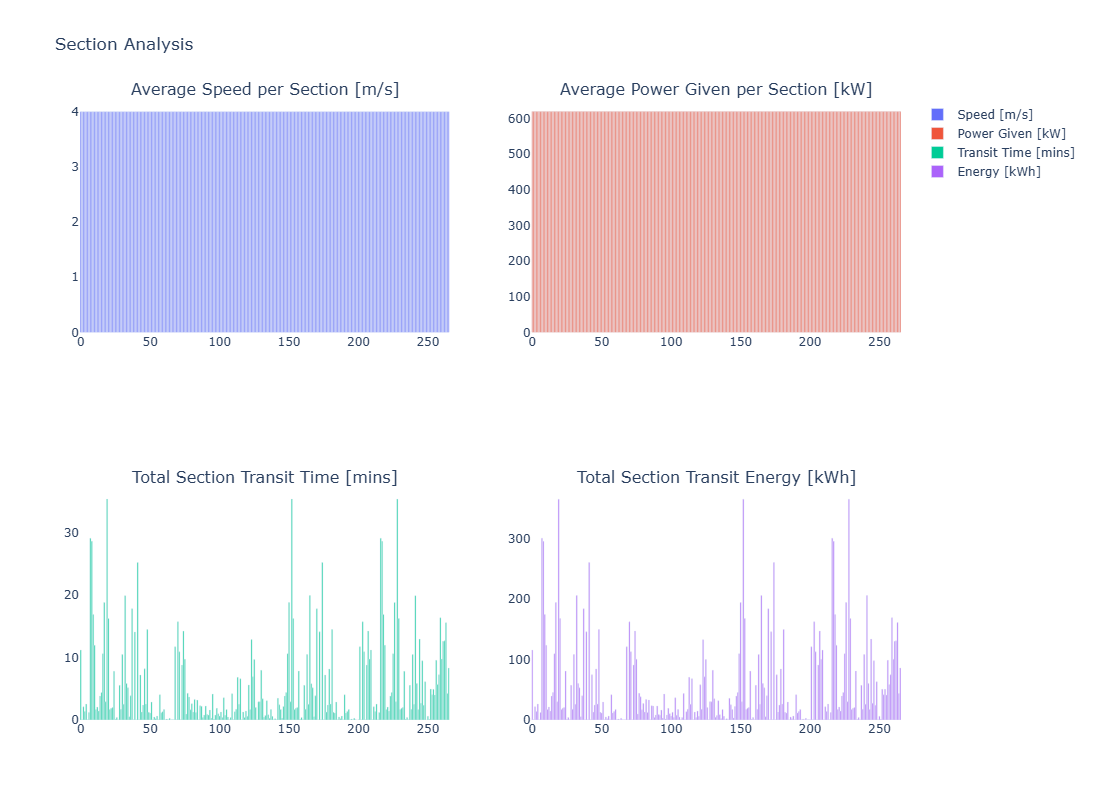

In [28]:
# Calculate average speed
average_speed = df_eventtable_energy_fuel['distance (m)'] / df_eventtable_energy_fuel['duration (s)']

# Calculate durations in minutes
durations = [
    (row['stop time'] - row['start time']).total_seconds() / 60
    for _, row in df_eventtable_energy_fuel.iterrows()
]

# Create 2x2 subplot figure
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    'Average Speed per Section [m/s]',
    'Average Power Given per Section [kW]',
    'Total Section Transit Time [mins]',
    'Total Section Transit Energy [kWh]'
])

# Add bar charts to subplots
fig.add_trace(go.Bar(x=df.index, y=average_speed, name='Speed [m/s]'), row=1, col=1)
fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_fuel['P_given (kW)'], name='Power Given [kW]'), row=1, col=2)
fig.add_trace(go.Bar(x=df.index, y=durations, name='Transit Time [mins]'), row=2, col=1)
fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_fuel['total_energy (kWh)'], name='Energy [kWh]'), row=2, col=2)

# Update layout
fig.update_layout(
    height=800,
    width=1000,
    title_text='Section Analysis',
    plot_bgcolor='white'
)

# fig.show()

Dont understand why the average speed is not constant at 4 m/s while I did define the vessel like that... 

In [29]:
# generate_vessel_gantt_chart(df_eventtable)

In [30]:
# Event totals + unit conversion + speed 
df_event = (
    df_eventtable
    .groupby('object name')
    .agg({'duration (s)': 'sum', 'distance (m)': 'sum'})
)
df_event['duration (h)']      = df_event['duration (s)'] / 3600
df_event['distance (km)']     = df_event['distance (m)'] / 1000
df_event['avg_speed_m_s']     = df_event['distance (m)'] / df_event['duration (s)']
# df_event['avg_speed_km_h']    = df_event['avg_speed_m_s'] * 3.6

# Diesel energy & fuel
df_fuel = (
    df_eventtable_energy_fuel
    .groupby('object name')
    .agg({'total_energy (kWh)': 'sum', 'diesel_consumption (g)': 'sum'})
)
df_fuel['diesel_consumption (kg)'] = df_fuel['diesel_consumption (g)'] / 1000
 
# H2 energy & fuel
df_H2 = (
    df_eventtable_energy_H2
    .groupby('object name')
    .agg({'total_energy (kWh)': 'sum', 'H2_consumption (g)': 'sum'})
)
df_H2['H2_consumption (kg)'] = df_H2['H2_consumption (g)'] / 1000

# Final summary table 
summary = (
    df_event
    .join(df_fuel[['total_energy (kWh)', 'diesel_consumption (kg)']])
    .join(df_H2[['H2_consumption (kg)']])
)

summary

,duration (s),distance (m),duration (h),distance (km),avg_speed_m_s,total_energy (kWh),diesel_consumption (kg),H2_consumption (kg)
object name,,,,,,,,
M9 Vessel passing NM+RS,29626.659050,118506.636201,8.229628,118.506636,4.0,5097.792976,1220.670701,351.478751
M9 Vessel passing NM+ZB,37771.733806,151086.935226,10.492148,151.086935,4.0,6499.297776,1556.262172,448.108637
M9 Vessel passing OM+RS,27123.310727,108493.242907,7.534253,108.493243,4.0,4667.047427,1117.528326,321.780035
M9 Vessel passing OM+ZB,35268.385483,141073.541932,9.796774,141.073542,4.0,6068.552228,1453.119798,418.409921


In [31]:
print("P_partial =", vessel_1.P_partial)
print("C_partial_load_PEMFC =", vessel_1.C_partial_load_PEMFC)

# Curious if this works too but it doesn't yet
# print("total_LH2_consumption_PEMFC_mass =", vessel.total_LH2_consumption_PEMFC_mass)

P_partial = 0.3539679715182371
C_partial_load_PEMFC = 1.0331743772145898


Makes sense that P_partial is constant throughout the trip because for some reason the P_given is constant too. I'm curious to see if that changes if the speed is constant. Basically dont understand why the speed changes anyways? The resistance is constant too right? Nothing changes on the waterway, depth is constant. Or is it not??? Yes it is 